# Sampling and standard error

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Recalling inferential statistics

- We want to make inferences aobut the population but only looking at one or mor random samples drawn from that population 

- With monte carlo simulation we can generate lots of random samples, and use them to compute confidence intervals by calculating the statistics of those trails

- But what if we coun't? What polls and survers usually do? why they only have one sample and not hundreds of them?

## Probability sampling

- Each member of the population has non-zero probabilty of being included in a sample

- **simple random sampling**: each member has an equal chance of being chosen

- Not always appropiate when we don't consider the characteristics of the population and how they are distributed


## Stratified sampling:

- Partition population into subgroups

- take a sipmle random sample from each subgroup, this is important when there are small subgroups that should be represented , and when it is important that those subgruops to be represented proportinally to their size in the poopulation

- But, it rquries care to do properly and well stick to simple random samples

## Data 

-  We are using dara from NCEI , daily high and low temperatures for 21 differnent US cities, from 1961 through 2015, 421848 rows.


# Functions

In [2]:
def makeHist(data, title, xlabel, ylabel, bins=20, ax=None):

    if ax is None:
        fig, ax = plt.subplots()

    ax.hist(data, bins=bins, color="#034794", alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [3]:
def getMeanAndSds(population, sample, verbose=False):

    popMean = sum(population) / len(population)

    sampleMean = sum(sample) / len(sample)

    if verbose:

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        makeHist(
            population,
            f"Daily High 1961 - 2015, Population \n \
                    mean = {round(popMean, 2)} Degrees C Number Days",
            "Degrees C",
            "Number Days",
            ax=axes[0],
        )
        makeHist(
            sample,
            f"Daily High 1961 - 2015, Sample \n \
                 (mean = {round(sampleMean, 2)}) ",
            "Degrees C",
            "Number Days",
            ax=axes[1],
        )
        plt.tight_layout()
        plt.show()
        print(f"Population mean = {popMean}")
        print(f"Standard deviation of population = {np.std(population)}")
        print(f"Sample Mean = {sampleMean} ")
        print(f"Standard deviation of sample = {np.std(sample)}")

    return popMean, sampleMean, np.std(population), np.std(sample)

In [4]:
## this can be totally done using pandas, but it is interesting to learn this methods
def getHighs():
    inFile = open("../data/temperatures.csv")
    population = []
    for l in inFile:
        try:
            tempC = float(l.split(",")[1])
            population.append(tempC)

        except:
            continue
    return population

# Reading the data

In [5]:
population = getHighs()
print(len(population))

421848


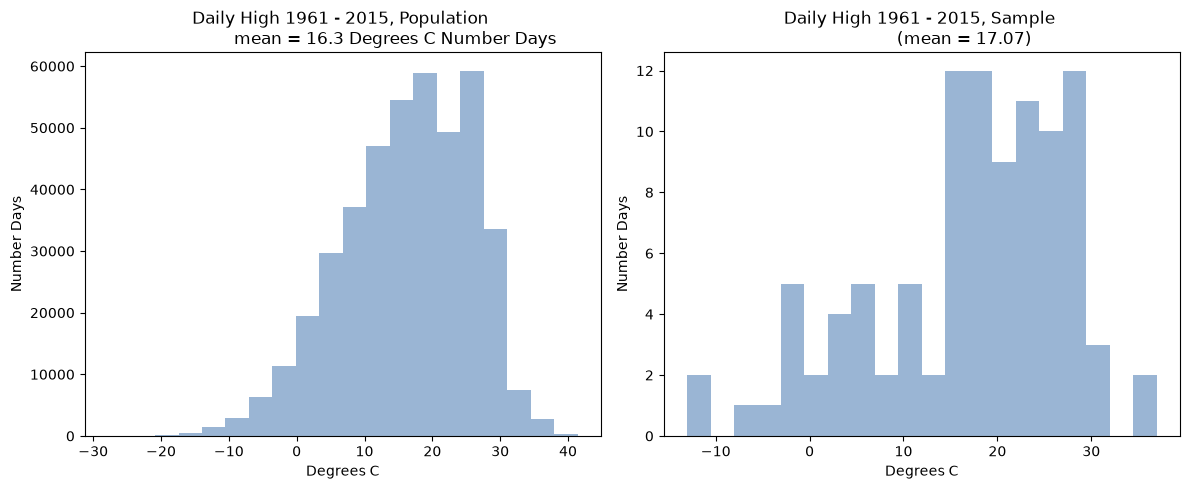

Population mean = 16.298769461986307
Standard deviation of population = 9.4375585448036
Sample Mean = 17.0685 
Standard deviation of sample = 10.390314372048614


In [6]:
random.seed(0)
sample = random.sample(population, 100)
popMean, sampleMean, stdPop, stdSample = getMeanAndSds(population, sample, True)

- Notice how the sample mean is not that far from the actual population mean!
- Lets try it 1000 times!

Mean of sample means = 16.294
Standard deviation pf sample means = 0.943


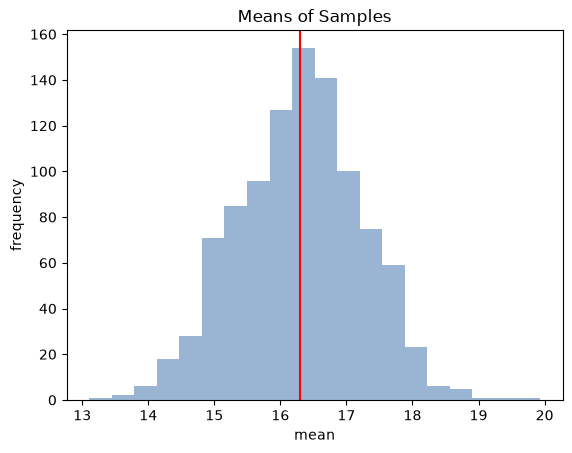

In [7]:
random.seed(0)
sampleSize = 100
numSamples = 1000
sampleMeans = []
for i in range(numSamples):
    sample = random.sample(population, sampleSize)
    popMean, sampleMean, popSD, sampleSD = getMeanAndSds(
        population, sample, verbose=False
    )
    sampleMeans.append(sampleMean)

print(f"Mean of sample means = {round(sum(sampleMeans)/ len(sampleMeans), 3)}")
print(f"Standard deviation pf sample means = {round(np.std(sampleMeans),3)}")

makeHist(sampleMeans, "Means of Samples", "mean", "frequency")
plt.axvline(x=popMean, color="r")
plt.show()

In [8]:
# lets compute confidence intervals:

upper = 16.294 + 1.96 * 0.943
lower = 16.294 - 1.96 * 0.943
print(upper, lower)

# includes the pop mean... but pretty wide!

18.14228 14.445720000000001


## Getting a tighter bound

- What can we do to have a lower bound? Increasing the number of samples? increasing the number of observatoins in the data

Mean of sample means = 16.282
Standard deviation pf sample means = 0.946


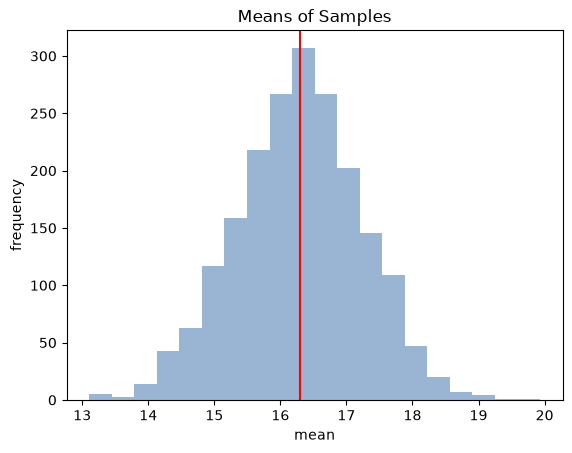

In [9]:
random.seed(0)
sampleSize = 100
numSamples = 2000
sampleMeans = []
for i in range(numSamples):
    sample = random.sample(population, sampleSize)
    popMean, sampleMean, popSD, sampleSD = getMeanAndSds(
        population, sample, verbose=False
    )
    sampleMeans.append(sampleMean)

print(f"Mean of sample means = {round(sum(sampleMeans)/ len(sampleMeans), 3)}")
print(f"Standard deviation pf sample means = {round(np.std(sampleMeans),3)}")

makeHist(sampleMeans, "Means of Samples", "mean", "frequency")
plt.axvline(x=popMean, color="r")
plt.show()

The standard deviation increased! from 0.943 to 0.946... a larger bound!

Lets try increasing the number of rows (observations in the sample n)

Mean of sample means = 16.282
Standard deviation pf sample means = 0.662


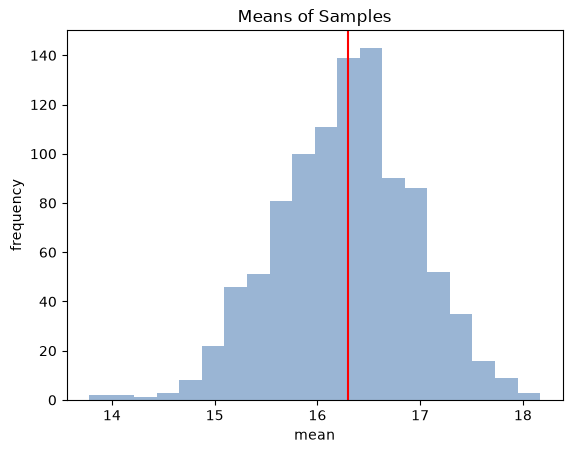

In [10]:
random.seed(0)
sampleSize = 200
numSamples = 1000
sampleMeans = []
for i in range(numSamples):
    sample = random.sample(population, sampleSize)
    popMean, sampleMean, popSD, sampleSD = getMeanAndSds(
        population, sample, verbose=False
    )
    sampleMeans.append(sampleMean)

print(f"Mean of sample means = {round(sum(sampleMeans)/ len(sampleMeans), 3)}")
print(f"Standard deviation pf sample means = {round(np.std(sampleMeans),3)}")

makeHist(sampleMeans, "Means of Samples", "mean", "frequency")
plt.axvline(x=popMean, color="r")
plt.show()

The stantard deviation decreased to 0.662... 

# Error bars , a Digression

- Error bars helps us to understand how the estimates of different categories or experiments hover around the confidence intervals

- It is a great way to visualize uncertainty! iF the CI do not overlap , means that there are statistical evidence to conclude means are significantly different at 95% level!

- But if they overlap... that means that we must investigate further



In [14]:
def showErrorBars(population, sizes, numTrials):

    xVals = []

    sizeMeans, sizeSDs = [], []

    for sampleSize in sizes:

        xVals.append(sampleSize)
        trialMeans = []

        for t in range(numTrials):
            sample = random.sample(population, sampleSize)
            popMean, sampleMean, popSD, sampleSD = getMeanAndSds(population, sample)
            trialMeans.append(sampleMean)

        sizeMeans.append(sum(trialMeans) / len(trialMeans))
        sizeSDs.append(np.std(trialMeans))

    print(sizeSDs)

    plt.errorbar(
        xVals,
        sizeMeans,
        yerr=1.96 * np.array(sizeSDs),
        fmt="o",
        label="95% Confidence Interval",
    )

    plt.title(f"Mean Temperature ({numTrials} trials)")
    plt.xlabel("Sample Size")
    plt.ylabel("mean")
    plt.axhline(y=popMean, color="r", label="Population mean")
    plt.xlim(0, sizes[-1] + 10)
    plt.legend()
    plt.show()

[np.float64(1.3187873740296425), np.float64(1.0053313241911843), np.float64(0.7064000708875957), np.float64(0.5175415224646231), np.float64(0.46485751939942577), np.float64(0.4474079925928905), np.float64(0.40235732871347646)]


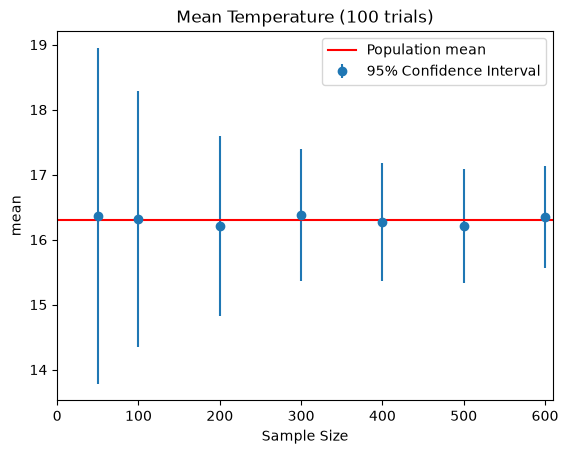

In [18]:
random.seed(0)
showErrorBars(population, (50, 100, 200, 300, 400, 500, 600), 100)

- Notice how those means are not the mean of only one sample, are the means of the samples originated in each trial

- SO larger samples seems to be better! but...

- we are cheating! Usally we are not supposed to access to the entire population data! The point is to make inferences using a small amount of data (just one sample, as election polls)

# Recalling central limit theroem:

1. The means of the samples in a set of samples (the sample means) will be approximately normal distributed as n gets larger

2. This normal distribution will be centered approximately to the mean population

3. The variance of the sample means will be close to the variance of the population divided by n 

Lets check the 3thd feature, **what can we conclude from only 1 sample?**

# Standard error of the mean

- The standard error is the standard deviation of the population divided by squared root of the the sample size!

- What is its relationship with the stantard deviation?

In [19]:
def sem(popSD, sampleSize):
    return popSD / sampleSize**0.5

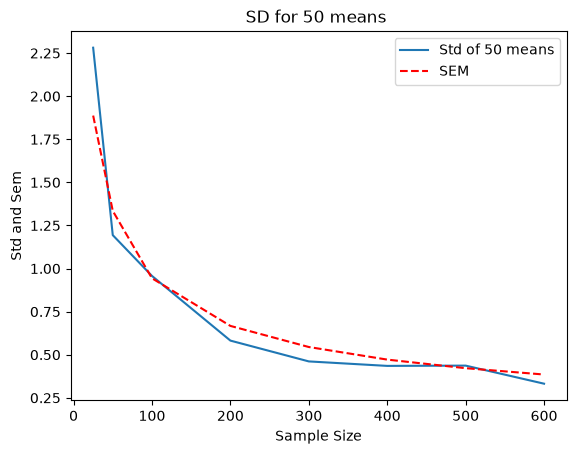

In [ ]:
sampleSizes = (25, 50, 100, 200, 300, 400, 500, 600)
numTrials = 50
popSD = np.std(population)
sems = []
sampleSDs = []
for size in sampleSizes:
    sems.append(sem(popSD, size))
    means = []
    for t in range(numTrials):
        sample = random.sample(population, size)
        means.append(sum(sample) / len(sample))

    sampleSDs.append(np.std(means))

plt.plot(
    sampleSizes, sampleSDs, label=f"Std of {numTrials} means"
)  # std form the samples
plt.plot(
    sampleSizes, sems, "r--", label="SEM"
)  # standard errors calculted form the population
plt.xlabel("Sample Size")
plt.ylabel("Std and Sem")
plt.title(f"SD for {numTrials} means ")
plt.legend()
plt.show()

- Of course there are differences... but basically both lines track each other so well,

- This is not a coincidence! It is just the third feature of the CLI, when the samples gets larger the sample standard deviation gets closer to the calculated standard error!

- So instead of sampling several times we can directly use the standard error, with only 1 sample! But with a catch... we need the population information! (std)

- and the only tool that we have to replace it is the sample std:


In [23]:
def plotDistribution():
    uniform, normal, exp = [], [], []

    for i in range(100000):
        uniform.append(random.random())
        normal.append(random.gauss(0, 1))
        exp.append(random.expovariate(0.5))

    makeHist(uniform, "Uniform", "value", "Frequency")
    makeHist(normal, "Gaussian", "value", "Frequency")
    makeHist(exp, "Expontential", "value", "Frequency")

In [32]:
def getDiffs(population, sampleSizes):
    popStd = np.std(population)
    diffsFracs = []
    for sampleSize in sampleSizes:
        diffs = []
        for t in range(100):
            sample = random.sample(population, sampleSize)
            diffs.append(abs(popStd - np.std(sample)))

        diffMean = sum(diffs) / len(diffs)
        diffsFracs.append(
            diffMean / popStd
        )  # how much difference ther is with respect to the pop std

    return np.array(diffsFracs) * 100


def plotDiffs(sampleSizes, diffs, title, label, color="b"):
    plt.plot(sampleSizes, diffs, label=label, color=color)
    plt.xlabel("Sapmle Size")
    plt.ylabel("% Difference in SD")
    plt.title(title)
    plt.legend()

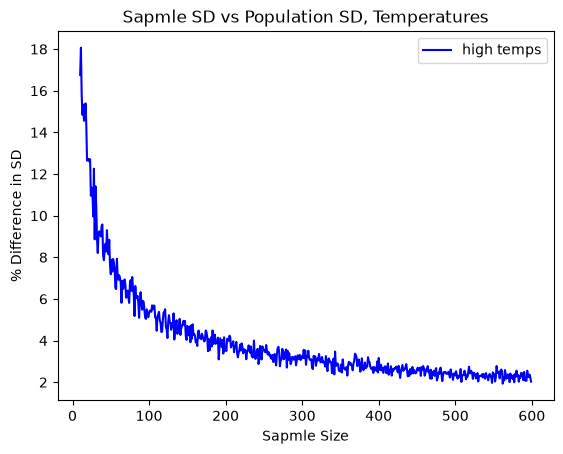

In [33]:
sampleSizes = range(10, 600, 1)
diffs = getDiffs(population, sampleSizes)
plotDiffs(
    sampleSizes, diffs, "Sapmle SD vs Population SD, Temperatures", label="high temps"
)

- If the sample size is large enoguh, the sample standard deviation is a really good aprox for the population std! around 2.5% with a 600 sample

- But, is this specific results for our data? can we generalize this to different types of distributions? for different sizes of the population?

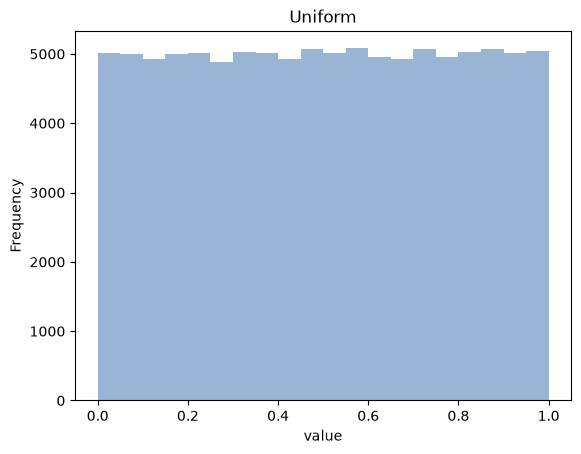

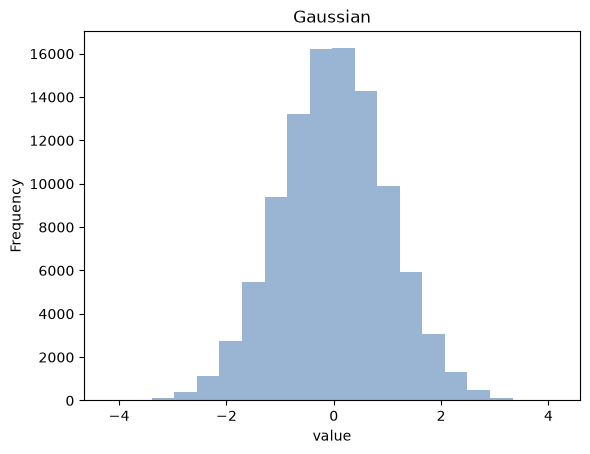

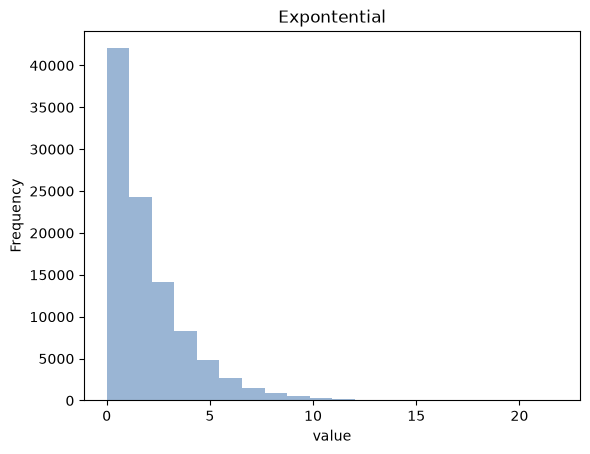

In [34]:
plotDistribution()

In [37]:
def compareDists():
    uniform, normal, exp = [], [], []

    for i in range(100000):
        uniform.append(random.random())
        normal.append(random.gauss(0, 1))
        exp.append(random.expovariate(0.5))

    sampleSizes = range(20, 600, 1)
    udiffs = getDiffs(uniform, sampleSizes)
    ndiffs = getDiffs(normal, sampleSizes)
    ediffs = getDiffs(exp, sampleSizes)

    plotDiffs(
        sampleSizes, udiffs, "Sample SD vs Population SD", "Uniform Population", "m"
    )
    plotDiffs(
        sampleSizes, ndiffs, "Sample SD vs Population SD", "Normal Population", "b"
    )

    plotDiffs(sampleSizes, ediffs, "Sample SD vs Population SD", "Exp Population", "r")

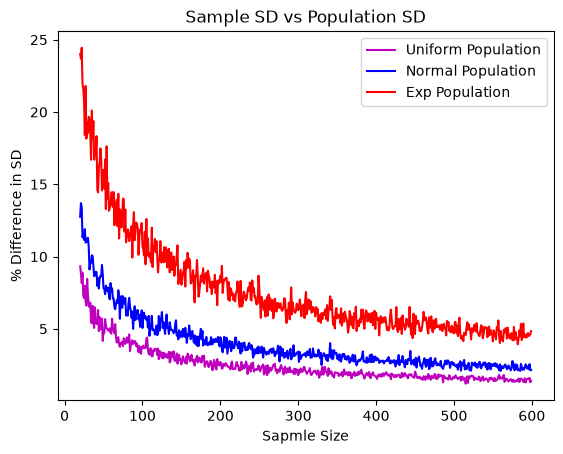

In [38]:
compareDists()

- The worst case would be for the exponential distribution, where we have 25% of difference with small sample sizes, 

- Even though, with a "big" sample of 600 , for the exp distrb we can reach differences around 6%

- Why does this happen? It is due tot he skewness! So when we need to decide how many samples, we have to check to the skewness!

- But what about size... does the size matter? NO!

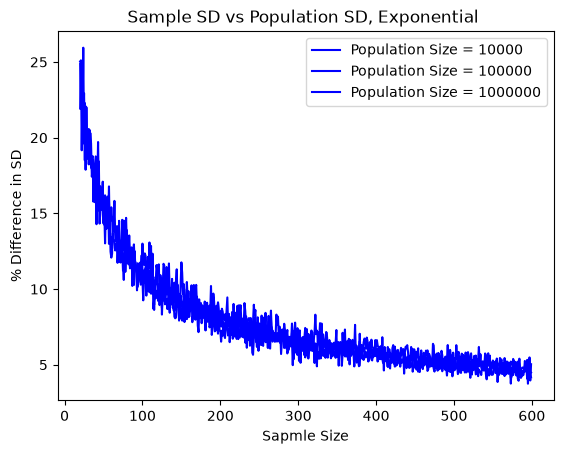

In [39]:
popSizes = (10000, 100000, 1000000)
sampleSizes = range(20, 600, 1)

for size in popSizes:
    population = []
    for i in range(size):
        population.append(random.expovariate(0.5))

    ediffs = getDiffs(population, sampleSizes)
    plotDiffs(
        sampleSizes,
        ediffs,
        "Sample SD vs Population SD, Exponential ",
        f"Population Size = {size}",
    )

Amazing! If you have a bigger population it does not need more samples! 

It soudns contra intituive, than for 10000 and 1000000 does not matter a lot if change the sample mean!

That is why political polls only survey around 1000 persons or a small amount

# To estimate Mean from a single sample:

1. Choose sample size based on estimate of the skew in population

2. Choose a random sample from the population 

3. Compute the mean and std for that sample 

4. Use the standard deviation of that sample to estimate the SE

In [42]:
temps = getHighs()
popMean = sum(temps) / len(temps)
sampleSize = 200
numTrials = 10000

In [ ]:
# bad experiment
random.seed(0)
numBad = 0

for t in range(numTrials):
    posStartingPts = range(0, len(temps) - sampleSize)
    start = random.choice(posStartingPts)
    sample = temps[start : start + sampleSize]
    sampleMean = sum(sample) / sampleSize
    se = np.std(sample) / sampleSize**0.5
    if abs(popMean - sampleMean) > 1.96 * se:
        numBad += 1

print(f"Fraction outside 95% confidence interval = {numBad/numTrials}")

Fraction outside 95% confidence interval = 0.8906


In [45]:
random.seed(0)
numBad = 0

for t in range(numTrials):
    sample = random.sample(temps, sampleSize)
    sampleMean = sum(sample) / sampleSize
    se = np.std(sample) / sampleSize**0.5
    if abs(popMean - sampleMean) > 1.96 * se:
        numBad += 1

print(f"Fraction outside 95% confidence interval = {numBad/numTrials}")

Fraction outside 95% confidence interval = 0.0511
